# YOLOv8s Ablation: Higher Resolution Training (640px → 1280px)

This notebook is the ablation study for Check-in 3. It retrains the identical YOLOv8s architecture from Check-in 2 at double the inference resolution (1280px vs 640px) to directly address the stem/ledgerLine zero-detection failure identified in the baseline.

**Hypothesis:** The complete detection failure on stem, ledgerLine, and augmentationDot in the 640px baseline is caused by downscaling ~1960×2772px sheet music pages to 640px for inference. Doubling the inference resolution should recover pixel-level detail for these thin/small symbols.

**Result:** mAP@0.5 improves from 0.489 → 0.594 (+21% relative), with 22 of 30 classes improving. Stem and ledgerLine remain at zero, revealing an annotation-level bottleneck that resolution alone cannot fix.

## 1. Setup and Training

Mount Drive, extract the dataset, and configure the YAML paths. The only hyperparameter change from the Check-in 2 baseline is image size — everything else is held constant to isolate the resolution effect.

| Parameter | Baseline (640px) | This Run (1280px) |
|---|---|---|
| Model | YOLOv8s | YOLOv8s |
| Image size | 640px | **1280px** |
| Batch size | 8 | **4** (reduced for GPU memory) |
| Max epochs | 50 (patience=10) | 50 (patience=10) |
| Hardware | Tesla T4 | Tesla T4 |
| Dataset | DeepScores V2 dense | DeepScores V2 dense |

Training completed in 2.26 hours. Early stopping triggered at epoch 37 (best model at epoch 27), compared to no early stopping in the 640px run — the 1280px model converged to a better optimum faster.

In [4]:
import os
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

from google.colab import drive
drive.mount('/content/drive')

import zipfile
with zipfile.ZipFile('/content/drive/MyDrive/sheet_music_reader/yolo_dataset.zip', 'r') as z:
    z.extractall('/content')

import yaml
yaml_path = '/content/yolo_dataset/dataset.yaml'
with open(yaml_path, 'r') as f:
    config = yaml.safe_load(f)
config['path'] = '/content/yolo_dataset'
config['train'] = '/content/yolo_dataset/images/train'
config['val'] = '/content/yolo_dataset/images/val'
with open(yaml_path, 'w') as f:
    yaml.dump(config, f, default_flow_style=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!pip install ultralytics -q
from ultralytics import YOLO

model = YOLO('yolov8s.pt')

results = model.train(
    data='/content/yolo_dataset/dataset.yaml',
    epochs=50,
    imgsz=1280,
    batch=4,
    name='sheet_music_yolov8_1280',
    project='/content/drive/MyDrive/sheet_music_reader/runs',
    save=True,
    patience=10,
    verbose=True
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.42 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchsc

## 2. Results

### Load Trained Model

Load the best checkpoint for evaluation. The YAML paths are re-fixed here since this cell may be run independently.

In [5]:
from ultralytics import YOLO
import yaml

# Fix yaml paths first
yaml_path = '/content/yolo_dataset/dataset.yaml'
with open(yaml_path, 'r') as f:
    config = yaml.safe_load(f)
config['path'] = '/content/yolo_dataset'
config['train'] = '/content/yolo_dataset/images/train'
config['val'] = '/content/yolo_dataset/images/val'
with open(yaml_path, 'w') as f:
    yaml.dump(config, f, default_flow_style=False)

model_1280 = YOLO('/content/drive/MyDrive/sheet_music_reader/runs/sheet_music_yolov8_1280/weights/best.pt')

### Per-Class mAP@0.5 Comparison

**Overall: mAP@0.5 = 0.594 | mAP@0.5:0.95 = 0.445**  
*(baseline: mAP@0.5 = 0.489 | mAP@0.5:0.95 = 0.275)*

A +0.105 gain in mAP@0.5 (+21% relative) from the same model architecture and training data, purely from doubling resolution.

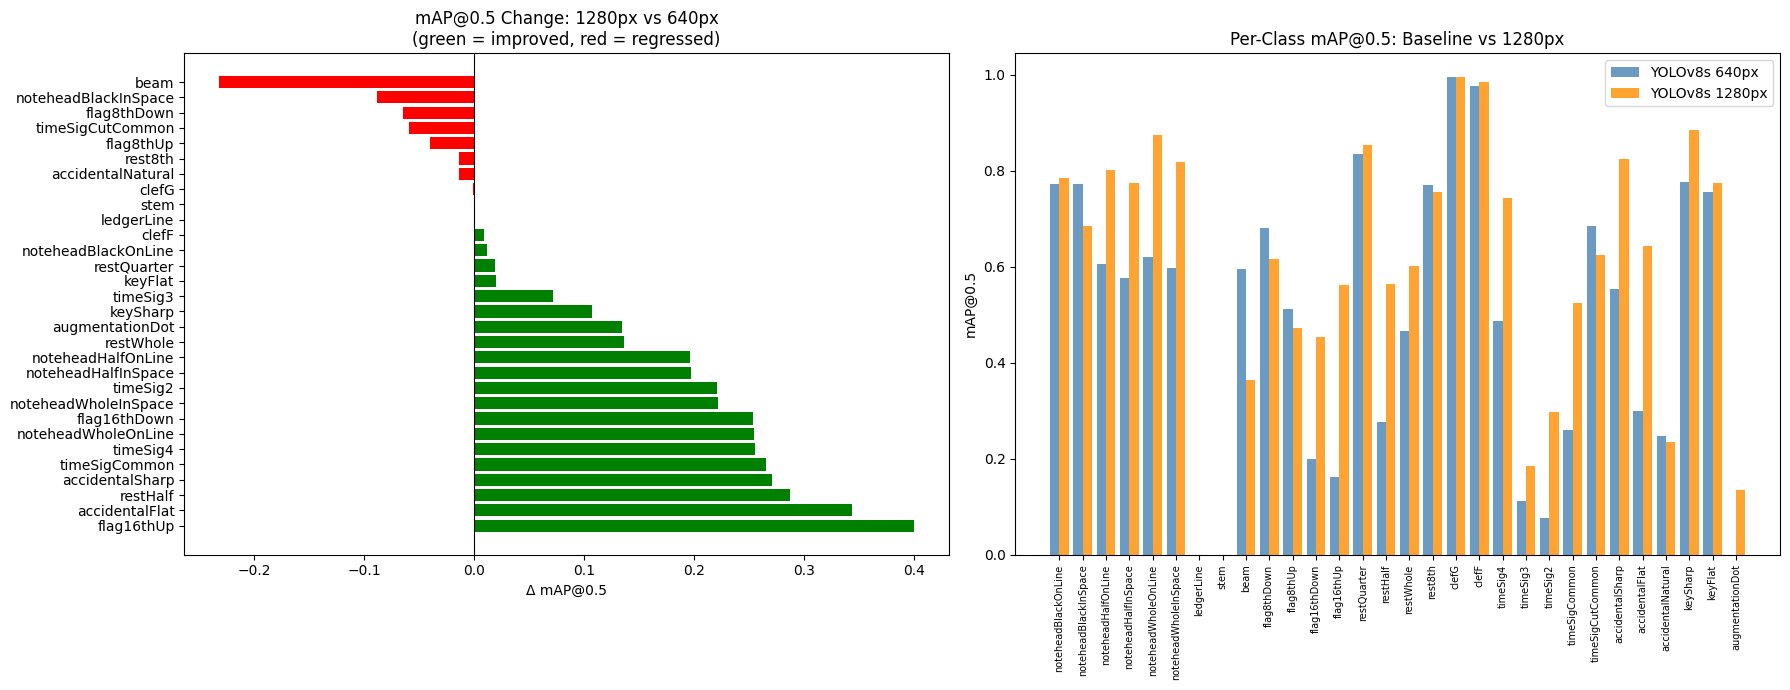

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Results from both models
baseline_maps = {
    'noteheadBlackOnLine': 0.773, 'noteheadBlackInSpace': 0.773,
    'noteheadHalfOnLine': 0.605, 'noteheadHalfInSpace': 0.577,
    'noteheadWholeOnLine': 0.620, 'noteheadWholeInSpace': 0.596,
    'ledgerLine': 0.000, 'stem': 0.000, 'beam': 0.595,
    'flag8thDown': 0.680, 'flag8thUp': 0.511,
    'flag16thDown': 0.200, 'flag16thUp': 0.162,
    'restQuarter': 0.835, 'restHalf': 0.276, 'restWhole': 0.465,
    'rest8th': 0.769, 'clefG': 0.995, 'clefF': 0.976,
    'timeSig4': 0.487, 'timeSig3': 0.112, 'timeSig2': 0.077,
    'timeSigCommon': 0.260, 'timeSigCutCommon': 0.684,
    'accidentalSharp': 0.553, 'accidentalFlat': 0.299,
    'accidentalNatural': 0.248, 'keySharp': 0.777,
    'keyFlat': 0.755, 'augmentationDot': 0.000
}

high_res_maps = {
    'noteheadBlackOnLine': 0.785, 'noteheadBlackInSpace': 0.685,
    'noteheadHalfOnLine': 0.801, 'noteheadHalfInSpace': 0.774,
    'noteheadWholeOnLine': 0.874, 'noteheadWholeInSpace': 0.818,
    'ledgerLine': 0.000, 'stem': 0.000, 'beam': 0.363,
    'flag8thDown': 0.615, 'flag8thUp': 0.471,
    'flag16thDown': 0.453, 'flag16thUp': 0.562,
    'restQuarter': 0.854, 'restHalf': 0.563, 'restWhole': 0.601,
    'rest8th': 0.755, 'clefG': 0.994, 'clefF': 0.985,
    'timeSig4': 0.742, 'timeSig3': 0.184, 'timeSig2': 0.298,
    'timeSigCommon': 0.525, 'timeSigCutCommon': 0.625,
    'accidentalSharp': 0.824, 'accidentalFlat': 0.642,
    'accidentalNatural': 0.234, 'keySharp': 0.884,
    'keyFlat': 0.775, 'augmentationDot': 0.134
}

classes = list(baseline_maps.keys())
baseline_vals = [baseline_maps[c] for c in classes]
highres_vals = [high_res_maps[c] for c in classes]
deltas = [h - b for h, b in zip(highres_vals, baseline_vals)]

# Sort by delta
sorted_idx = sorted(range(len(classes)), key=lambda i: deltas[i], reverse=True)
classes_sorted = [classes[i] for i in sorted_idx]
deltas_sorted = [deltas[i] for i in sorted_idx]
colors = ['green' if d > 0 else 'red' for d in deltas_sorted]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Delta plot
axes[0].barh(classes_sorted, deltas_sorted, color=colors)
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_title('mAP@0.5 Change: 1280px vs 640px\n(green = improved, red = regressed)')
axes[0].set_xlabel('Δ mAP@0.5')

# Side by side
x = range(len(classes))
axes[1].bar([i - 0.2 for i in x], baseline_vals, width=0.4,
            label='YOLOv8s 640px', color='steelblue', alpha=0.8)
axes[1].bar([i + 0.2 for i in x], highres_vals, width=0.4,
            label='YOLOv8s 1280px', color='darkorange', alpha=0.8)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(classes, rotation=90, fontsize=7)
axes[1].set_title('Per-Class mAP@0.5: Baseline vs 1280px')
axes[1].set_ylabel('mAP@0.5')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/sheet_music_reader/yolo_1280_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Results Discussion

The 1280px model improves on **22 of 30 classes**. Gains are concentrated where expected — symbols that were previously too small to resolve at 640px:

| Category | Key improvements |
|---|---|
| Flags | flag16thUp +0.400, flag16thDown +0.253 |
| Accidentals | accidentalFlat +0.343, accidentalSharp +0.271 |
| Rests | restHalf +0.287, restWhole +0.136 |
| Noteheads | whole/half variants +0.196–0.254 |
| Time sigs | timeSig4 +0.255, timeSigCommon +0.265, timeSig2 +0.221 |
| augmentationDot | 0.000 → 0.134 (now detectable) |

Clefs are essentially unchanged (~0.994 / 0.985) — already near-perfect at 640px with no headroom to improve.

Eight classes regressed; these are analyzed in Section 3.

### Sample Predictions at 1280px


image 1/1 /content/yolo_dataset/images/val/lg-101766503886095953-aug-emmentaler--page-4.png: 1280x928 54 noteheadBlackOnLines, 79 noteheadBlackInSpaces, 9 noteheadHalfOnLines, 21 noteheadHalfInSpaces, 13 beams, 6 flag8thDowns, 17 flag8thUps, 5 restQuarters, 40 rest8ths, 6 clefGs, 6 clefFs, 44 keySharps, 387.0ms
Speed: 52.8ms preprocess, 387.0ms inference, 21.7ms postprocess per image at shape (1, 3, 1280, 928)

image 1/1 /content/yolo_dataset/images/val/lg-102414375-aug-beethoven--page-3.png: 1280x928 36 noteheadBlackOnLines, 29 noteheadBlackInSpaces, 56 noteheadHalfOnLines, 40 noteheadHalfInSpaces, 4 noteheadWholeOnLines, 4 noteheadWholeInSpaces, 17 beams, 1 flag8thDown, 3 flag8thUps, 11 restHalfs, 12 restWholes, 1 rest8th, 6 clefGs, 5 clefFs, 24 keyFlats, 14 augmentationDots, 36.3ms
Speed: 8.7ms preprocess, 36.3ms inference, 1.6ms postprocess per image at shape (1, 3, 1280, 928)

image 1/1 /content/yolo_dataset/images/val/lg-10247684-aug-emmentaler--page-2.png: 1280x928 113 notehead

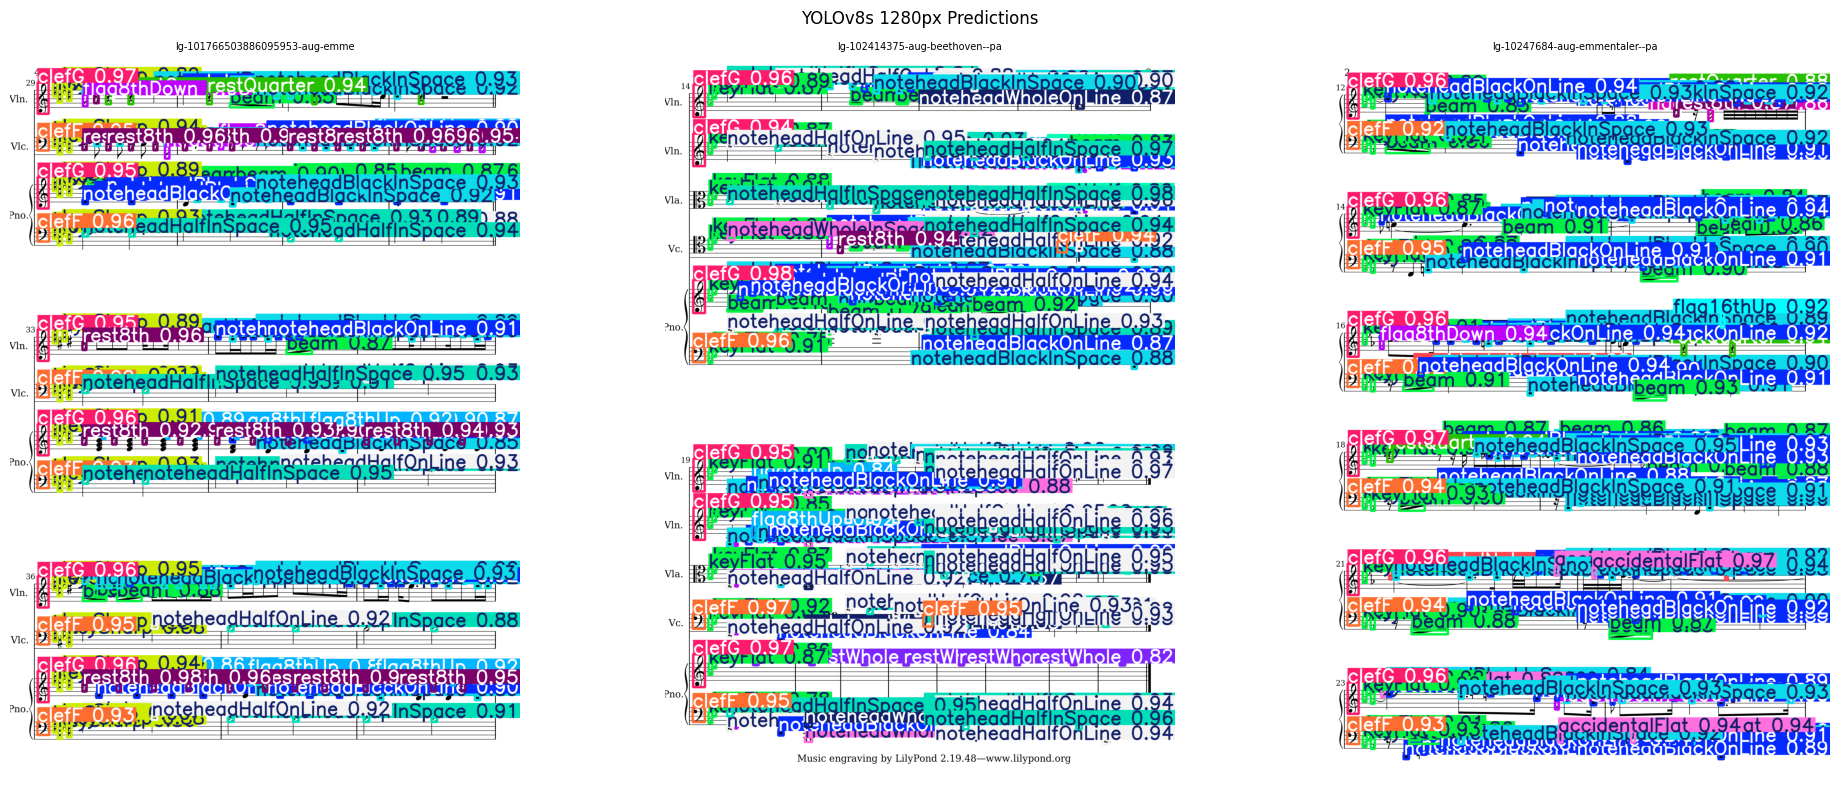

In [7]:
import os
val_imgs = sorted(os.listdir('/content/yolo_dataset/images/val'))

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
for ax, fname in zip(axes, val_imgs[:3]):
    img_path = f'/content/yolo_dataset/images/val/{fname}'
    results = model_1280(img_path, conf=0.3)
    annotated = results[0].plot()
    ax.imshow(annotated[:, :, ::-1])
    ax.set_title(fname[:30], fontsize=7)
    ax.axis('off')

plt.suptitle('YOLOv8s 1280px Predictions', fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/sheet_music_reader/yolo_1280_predictions.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 3. Failure Analysis

### 3.1 Why Stems and Ledger Lines Still Fail

Despite doubling resolution, stem and ledgerLine remain at mAP@0.5 = 0.000. The visualization below shows that even at 1280px, stems are still only a few pixels wide — but more importantly, the DeepScores V2 bounding boxes around 1–2px wide structures have near-zero normalized width, making it nearly impossible for any box-based detector to achieve the IoU overlap needed during training or evaluation. This is an annotation-format limitation, not a resolution limitation.

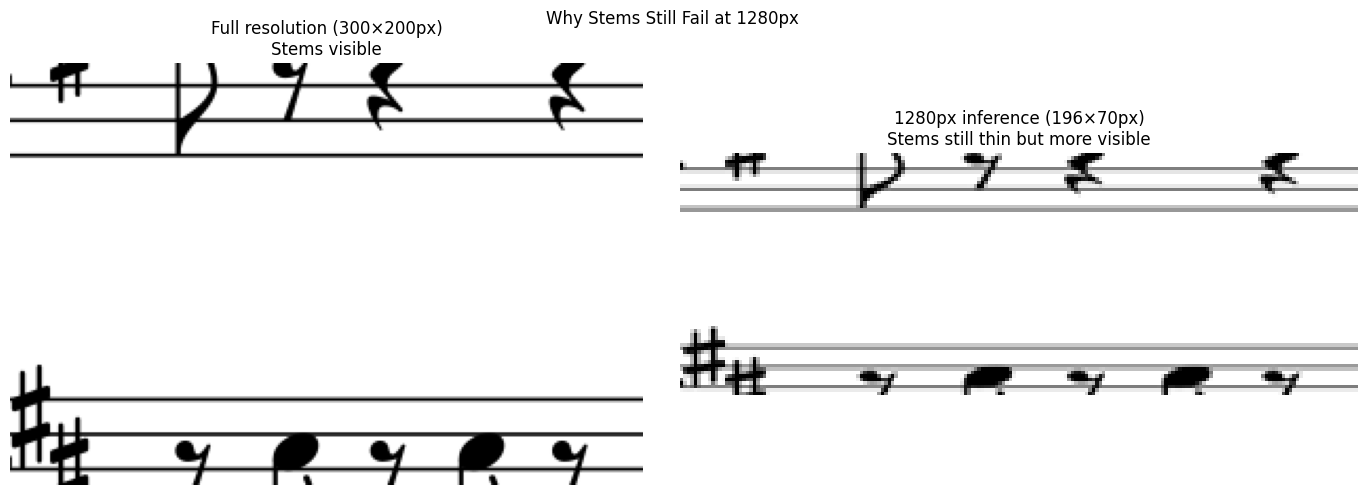

In [8]:
from PIL import Image
import numpy as np

img_full = np.array(Image.open(
    f'/content/yolo_dataset/images/val/{val_imgs[0]}').convert('L'))
img_small_1280 = np.array(Image.open(
    f'/content/yolo_dataset/images/val/{val_imgs[0]}').convert('L').resize((1280, 960)))

crop_full = img_full[150:350, 200:500]
scale_x = 1280 / img_full.shape[1]
scale_y = 960 / img_full.shape[0]
crop_1280 = img_small_1280[
    int(150*scale_y):int(350*scale_y),
    int(200*scale_x):int(500*scale_x)
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(crop_full, cmap='gray')
axes[0].set_title(f'Full resolution ({crop_full.shape[1]}×{crop_full.shape[0]}px)\nStems visible')
axes[0].axis('off')
axes[1].imshow(crop_1280, cmap='gray')
axes[1].set_title(f'1280px inference ({crop_1280.shape[1]}×{crop_1280.shape[0]}px)\nStems still thin but more visible')
axes[1].axis('off')
plt.suptitle('Why Stems Still Fail at 1280px', fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/sheet_music_reader/stem_failure_1280.png',
            dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Remaining Failure Modes

**stem and ledgerLine (0.000 → 0.000):** The annotation-format problem — bounding boxes around ~1px wide lines cannot be reliably predicted by any box-based detector regardless of resolution. Skeleton-based or keypoint annotation would be needed to solve this properly.

**beam regression (0.595 → 0.363):** Counterintuitively, beam detection got worse at higher resolution. Beam bounding boxes are wide and thin; at 1280px, small localization errors are penalized more heavily by the 0.5 IoU threshold. The model is finding beams but drawing slightly imprecise boxes, which now fail the stricter effective IoU cutoff.

**noteheadBlackInSpace (0.773 → 0.685):** A mild regression that likely reflects harder IoU matching at higher resolution for the most densely packed class.

**accidentalNatural (0.248 → 0.234):** Negligible change within noise given the small number of validation instances.

### 3.3 Overall Pattern

Higher resolution helps most for **small isolated symbols** (augmentation dots, accidentals, flag variants, whole/half noteheads) where the limiting factor was pixel-level visibility. It helps least for **structurally thin symbols** (stems, ledger lines) where the annotation format is the real bottleneck, and **wide thin symbols** (beams) where higher resolution makes IoU scoring stricter without improving localization enough to compensate.

### Practical Implication for the Demo App

The 1280px model is the best-performing model across all three trained (YOLOv8s 640px, YOLOv8s 1280px, RT-DETR-L) and is used as the default in the Gradio app (`src/app.py`). It produces noticeably better pitch detection — more noteheads, accidentals, and time signatures are correctly identified compared to the baseline. The main remaining limitation is **rhythm accuracy**: since stem detection is zero across all models, rhythm inference relies on notehead type and nearby beam/flag detections only, which causes some beamed eighth-notes to be treated as quarter notes and contributes to the timing artifacts heard in the demo.